# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:**
**Student ID:**
**Section:**
**GitHub Profile:**
**Kaggle Profile:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [317]:
# # YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
df = pd.read_csv("clean_churn.csv")

---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [318]:
# # Task 1 — load and verify the cleaned dataset
df = pd.read_csv("clean_churn.csv")
print("Shape: " , df.shape)

#Data types 
print("\nDataset Information: ")
df.info()

#Missing Values
print("\nMissing Values: ")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())



Shape:  (7043, 20)

Dataset Information: 
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMeth

**Answer 2:**
_(**Problem statement:** We are predicting `Churn` — whether a Telco customer will cancel (leave) the
service — as a binary classification problem (Yes/No), using the customer's account, service, and billing
attributes as predictors.)_

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [319]:
# Additional verification if needed (dtypes, target check, etc.)
print("Shape: ", df.shape)
df.head()
df.info()

Shape:  (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   

---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [320]:
# Task 3 — define y and X
# Encode target column
y = df['Churn'].map({"No": 0, "Yes": 1})

In [321]:
# Task 4 — encode categorical columns in X
X = df.drop(columns=['Churn'])
X = pd.get_dummies(X, drop_first=True)
X.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [322]:
# Task 5 — confirm X is fully numeric with no missing values
print(X.dtypes)
print("Any missing value: ", X.isnull().sum().sum())

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

**Answer 4 (encoding method & justification):**
_(your answer here)_

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [323]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [324]:
# Task 7 — report shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5634, 30) (1409, 30) (5634,) (1409,)


**Answer 6 (why stratify=y):**
_(your answer here)_

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [325]:
# Task 8 — train baseline Decision Tree and predict on train/test
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)
y_train_pred=clf.predict(X_train)


In [326]:
# Task 9 — check the fitted tree's depth
print("Depth", clf.get_depth())

Depth 23


**Answer 9:**
_(your answer here)_

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [327]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
metrics = {"Accuracy": accuracy_score(y_test, y_pred), "Precision": precision_score(y_test, y_pred), "Recall": recall_score(y_test, y_pred), "F1": f1_score(y_test, y_pred)}
print(pd.DataFrame([metrics]))

   Accuracy  Precision   Recall        F1
0  0.726047   0.483784  0.47861  0.481183


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy | 0.726047 |
| Precision | 0.43784 |
| Recall | 0.47861 |
| F1-score | 0.481183 |

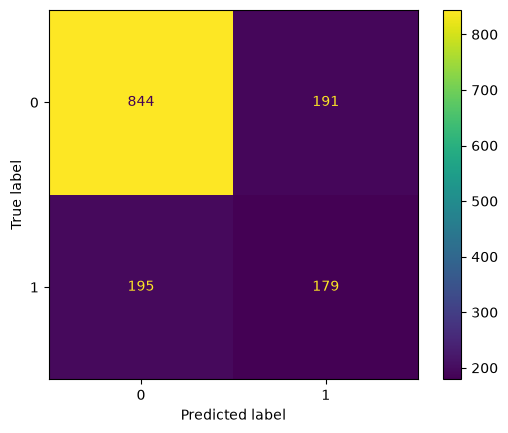

In [328]:
# Task 11 — plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)


**Answer 11 (churners correctly caught vs. missed):**
_(your answer here)_

**Answer 12 (which metric(s) do you trust most, and why):**
_(your answer here)_

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [329]:
# Task 13 — compare baseline train vs. test accuracy
print("Train:", accuracy_score(y_train, y_train_pred)); print("Test", accuracy_score(y_test,y_pred))

Train: 0.9980475683351083
Test 0.7260468417317246


**Answer 13:**
_(your answer here)_

In [330]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
train_accs = []
test_accs =[]

for d in depths:
    tree_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree_d.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree_d.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree_d.predict(X_test)))

depth_results = pd.DataFrame({
    "max_depth": [str(d) for d in depths],
    "Train Accuracy": train_accs,
    "Test Accuracy": test_accs
})
print(depth_results)


  max_depth  Train Accuracy  Test Accuracy
0         2        0.791090       0.787083
1         3        0.791090       0.787083
2         4        0.792510       0.795600
3         5        0.802272       0.794180
4         6        0.810614       0.800568
5         8        0.835818       0.782825
6        10        0.872737       0.755145
7      None        0.998048       0.726047


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 | 0.791090 | 0.7871 |
| 3 | 0.791090 | 0.7871 |
| 4 | 0.792510 | 0.7956 |
| 5 | 0.801272 | 0.7942 |
| 6 | 0.8071 | 0.7970 |
| 8 | 0.8349 | 0.7800 |
| 10 | 0.8722 | 0.7559 |
| None | 0.9980 | 0.7417 |

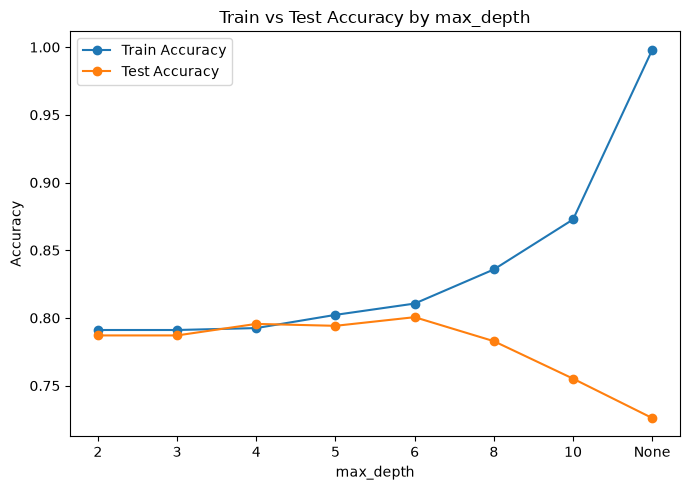

In [331]:
# Task 15 — plot train vs. test accuracy against max_depth
labels = [str(d) for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(7, 5))
plt.plot(x_pos, train_accs, marker="o", label="Train Accuracy")
plt.plot(x_pos, test_accs, marker="o", label="Test Accuracy")
plt.xticks(x_pos, labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by max_depth")
plt.legend()
plt.tight_layout()
plt.show()

**Answer 15 (where overfitting starts, and why):**
_(your answer here)_

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
_(your answer here)_

In [332]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
best_depth=5
best=DecisionTreeClassifier(max_depth=best_depth,random_state=42).fit(X_train,y_train)
p=best.predict(X_test)
print(pd.DataFrame([{"Accuracy":accuracy_score(y_test,p),"Precision":precision_score(y_test,p),"Recall":recall_score(y_test,p),"F1":f1_score(y_test,p)}]))


   Accuracy  Precision    Recall        F1
0   0.79418    0.63125  0.540107  0.582133


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = ___) |
|---|---|---|
| Accuracy |0.79488 | |
| Precision | 0.6312| |
| Recall | 0.540104| |
| F1-score | 0.562133| |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

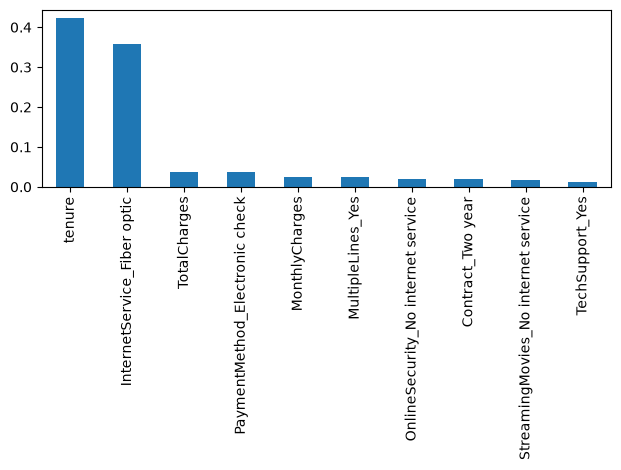

tenure                                 0.422047
InternetService_Fiber optic            0.358061
TotalCharges                           0.037156
PaymentMethod_Electronic check         0.036814
MonthlyCharges                         0.025461
MultipleLines_Yes                      0.023665
OnlineSecurity_No internet service     0.020699
Contract_Two year                      0.019628
StreamingMovies_No internet service    0.017404
TechSupport_Yes                        0.013007
dtype: float64


In [333]:
# Task 18 — extract and visualize feature importances
import matplotlib.pyplot as plt
fi=pd.Series(best.feature_importances_,index=X.columns).sort_values(ascending=False).head(10)
fi.plot(kind="bar")
plt.tight_layout();plt.show()
print(fi)


**Answer 18 (top 3–5 features):**
_(your answer here)_

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**
_(your answer here)_

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
_(your answer here)_

**Answer 21 — Next steps:**
_(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted